# Processamento de dados: BOLD5000

In [ ]:
import os
import re
import gc
import json
import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from typing import Tuple, Set
from sklearn.model_selection import train_test_split

DATA_DIRS = ["/home/al.pedro.alberti/Downloads/dataset/bold5000/PAR1"]
SUBJECTS = ["CSI1"] # Only 1 subject used, if wanted to use more subjects, 
                    # remember to change the dataloader.py file

# Where the processed data will be put 
BASE_OUTPUT     = "/home/al.pedro.alberti/Downloads/dataset/data"
OUTPUT_DIR_TREINO = os.path.join(BASE_OUTPUT, "processed/train")
OUTPUT_DIR_TESTE  = os.path.join(BASE_OUTPUT, "processed/test")

# This file has 13GB of size, so I couldn't put it on the github
COCO_ANNOTATIONS = "/mnt/storage_C1/PedroAlberti/ml2/ml2_trabalhos_2026/trabalho_final/cnn_final/data_loader/auxiliar/instances_train2014.json"

TARGET_SHAPE = (91, 109, 91) # Output, where the dimensions are: 
TRS          = ["TR1", "TR2", "TR3", "TR4", "TR5"]
TEST_SIZE    = 0.2
RANDOM_STATE = 42

# Mapeamento supercategoria COCO → label interno
SUPERCAT_MAP = {
    "person":      0, "animal":      1, "vehicle":     2,
    "food":        3, "furniture":   3, "sports":      3,
    "outdoor":     3, "indoor":      3, "kitchen":     3, 
    "electronic":  3, "appliance":   3, "accessory":   3,
}
 
NOMES_CLASSES = {
    0: "Pessoa",
    1: "Animal",
    2: "Veículo",
    3: "Objetos/Cenário",
}
 
CORES = ["#E63946", "#2A9D8F", "#E9C46A", "#264653"]

### Funções Auxiliares

In [ ]:
def build_imageid_to_supercat(annotations_path: str) -> dict:
    """
    Carrega o JSON oficial do COCO e monta: image_id (int) → label interno (int)

    Para imagens com múltiplas categorias, usa a supercategoria mais frequente.
    """
    print(f"[coco] Carregando anotações de: {annotations_path} ...")
    with open(annotations_path) as f:
        coco_data = json.load(f)

    # category_id → label interno
    cat_to_label = {}
    for cat in coco_data["categories"]:
        label = SUPERCAT_MAP.get(cat["supercategory"], 3)
        cat_to_label[cat["id"]] = label

    # Vota a supercategoria dominante por imagem
    image_label_votes = {}
    for ann in coco_data["annotations"]:
        img_id = ann["image_id"]
        label  = cat_to_label.get(ann["category_id"], 3)
        if img_id not in image_label_votes:
            image_label_votes[img_id] = Counter()
        image_label_votes[img_id][label] += 1

    image_to_label = {
        img_id: votes.most_common(1)[0][0]
        for img_id, votes in image_label_votes.items()
    }

    print(f"[coco] {len(image_to_label):,} imagens catalogadas.")
    return image_to_label


def extract_coco_id(imgname: str) -> int:
    """
    Extrai o image_id numérico do nome do arquivo COCO via regex.
    Ex: 'COCO_train2014_000000420713.jpg' → 420713
    """
    stem    = Path(imgname).stem
    numeros = re.findall(r'\d+', stem)
    if len(numeros) >= 2:
        return int(numeros[1])
    elif len(numeros) == 1:
        return int(numeros[0])
    return -1


def load_imgnames(data_dir: str, subject: str) -> list:
    """Lê o imgnames.txt e retorna lista de nomes de arquivo por trial."""
    path = os.path.join(data_dir, f"{subject}_imgnames.txt")
    with open(path) as f:
        names = [l.strip() for l in f if l.strip()]
    print(f"[labels] {subject}: {len(names)} trials no total")
    return names


def load_trial_from_tr(path: str, trial_idx: int, target: tuple) -> torch.Tensor:
    """Carrega apenas um trial do TR, normaliza e faz resize."""

    vol = nib.load(path)

    trial = np.asarray(vol.dataobj[:, :, :, trial_idx], dtype=np.float32)

    trial = np.nan_to_num(trial, nan=0.0, posinf=0.0, neginf=0.0)

    mean = trial.mean()
    std  = trial.std()

    if std < 1e-8:
        std = 1.0

    trial = (trial - mean) / std

    return resize_volume(trial, target)


def resize_volume(vol: np.ndarray, target: tuple) -> torch.Tensor:
    """
    1. Substitui NaN/Inf por 0
    2. Redimensiona (X,Y,Z) → target via interpolação trilinear
    """
    vol = np.nan_to_num(vol, nan=0.0, posinf=0.0, neginf=0.0)
    t   = torch.tensor(vol).unsqueeze(0).unsqueeze(0).float()  # (1,1,X,Y,Z)
    t   = F.interpolate(t, size=target, mode='trilinear', align_corners=False)
    return t.squeeze(0).squeeze(0)                             # (91,109,91)


def make_split(coco_indices: list, image_to_label: dict) -> Tuple[Set, Set]:
    """
    Faz o split treino/teste baseado em image_id único (não em índice de trial),
    com stratify para manter proporção de classes.
    Evita leakage de imagens repetidas.

    Retorna dois sets de coco_ids: train_ids, test_ids
    """
    # IDs únicos e seus labels
    ids_vistos = {}
    for _, coco_id in coco_indices:
        if coco_id not in ids_vistos:
            ids_vistos[coco_id] = image_to_label.get(coco_id, 3)

    ids_unicos    = list(ids_vistos.keys())
    labels_unicos = [ids_vistos[cid] for cid in ids_unicos]

    train_ids, test_ids = train_test_split(
        ids_unicos,
        test_size=TEST_SIZE,
        stratify=labels_unicos,
        random_state=RANDOM_STATE,
    )
    print(f"[split] {len(train_ids)} imagens únicas em treino | {len(test_ids)} em teste")
    return set(train_ids), set(test_ids)

def plot_final_distribution(contador_train: Counter, contador_test: Counter, titulo: str = "BOLD5000"):
    """
    Plota a distribuição final das classes nos conjuntos de treino e teste.
    """
    classes = sorted(NOMES_CLASSES.keys())

    nomes = [NOMES_CLASSES[c] for c in classes]

    valores_train = [contador_train[c] for c in classes]
    valores_test  = [contador_test[c] for c in classes]

    x = np.arange(len(classes))
    largura = 0.35

    plt.figure(figsize=(10, 6))

    bars_train = plt.bar(
        x - largura/2,
        valores_train,
        largura,
        color=COLORS[:len(classes)],
        edgecolor="black",
        alpha=0.9
    )

    bars_test = plt.bar(
        x + largura/2,
        valores_test,
        largura,
        color=COLORS[:len(classes)],
        edgecolor="black",
        alpha=0.55
    )

    plt.xticks(x, nomes)

    plt.title(
        f"Distribuição Semântica — {titulo}",
        fontsize=14,
        fontweight="bold"
    )

    plt.ylabel("Número de trials")
    plt.xlabel("Supercategoria")

    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    for bar in bars_train:

        h = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            h,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    for bar in bars_test:

        h = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            h,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

### Processamento dos dados 

[coco] Carregando anotações de: /mnt/storage_C1/PedroAlberti/ml2/ml2_trabalhos_2026/trabalho_final/cnn_final/data_loader/auxiliar/instances_train2014.json ...
[coco] 82,081 imagens catalogadas.

Processando: CSI1
[labels] CSI1: 5254 trials no total
[filter] 2135 trials COCO de 5254 totais
[split] 1600 imagens únicas em treino | 400 em teste
[save] Salvando 2135 arquivos .p...
  [0/2135] y=3 (Objetos/Cenário) | test
  [500/2135] y=3 (Objetos/Cenário) | train
  [1000/2135] y=2 (Veículo) | test
  [1500/2135] y=3 (Objetos/Cenário) | train
  [2000/2135] y=3 (Objetos/Cenário) | train


No handles with labels found to put in legend.


[done] CSI1


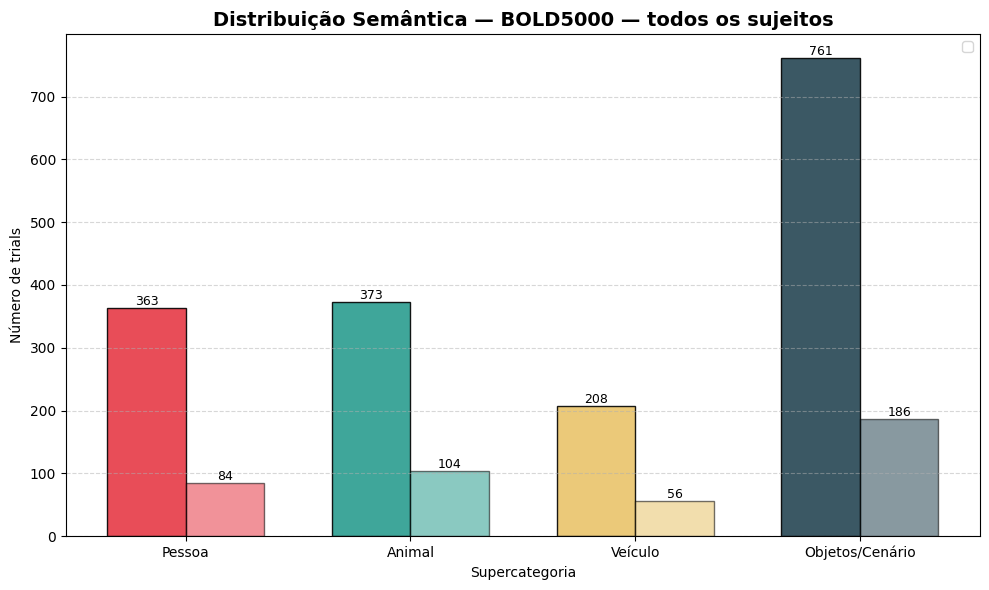

In [ ]:
image_to_label_dict = build_imageid_to_supercat(COCO_ANNOTATIONS)
contador_geral      = Counter()

for data_dir, subject in zip(DATA_DIRS, SUBJECTS):

    out_treino = os.path.join(OUTPUT_DIR_TREINO, subject)
    out_teste  = os.path.join(OUTPUT_DIR_TESTE,  subject)
    os.makedirs(out_treino, exist_ok=True)
    os.makedirs(out_teste,  exist_ok=True)

    print(f"\n{'='*60}")
    print(f"Processando: {subject}")
    print(f"{'='*60}")

    # 1. Nomes de imagem
    imgnames = load_imgnames(data_dir, subject)
    n_trials = len(imgnames)

    # 2. Coleta índices COCO válidos (com coco_id extraído)
    coco_indices = [
        (i, extract_coco_id(imgnames[i]))
        for i in range(n_trials)
        if Path(imgnames[i]).stem.startswith("COCO")
    ]
    print(f"[filter] {len(coco_indices)} trials COCO de {n_trials} totais")

    # 3. Split por image_id único com stratify
    train_ids, test_ids = make_split(coco_indices, image_to_label_dict)

    # Contadores de treino e teste
    contador_train = Counter()
    contador_test  = Counter()
    
    # 4. Monta e salva os .p no MESMO FORMATO DO NSD
    print(f"[save] Salvando {len(coco_indices)} arquivos .p...")
    for trial_num, (i, coco_id) in enumerate(coco_indices):
        raw_name = imgnames[i]
        y = image_to_label_dict.get(coco_id, 3)
        contador_geral[y] += 1

        # Carrega os 5 TRs
        channels = []
        for tr in TRS:
            path = os.path.join(data_dir, f"{subject}_SPMResids_allsess_{tr}.nii")
            channels.append(load_trial_from_tr(path, i, TARGET_SHAPE))

        X = torch.stack(channels, dim=0)  # (5, 91, 109, 91)

        if coco_id in train_ids:
            destino = os.path.join(out_treino, f"trial{trial_num:05d}.p")
            contador_train[y] += 1
        else:
            destino = os.path.join(out_teste, f"trial_{trial_num:05d}.p")
            contador_test[y] += 1

        # ✅ FORMATO PADRONIZADO (igual ao NSD)
        torch.save({
            'X':        X,           # tensor(5, 91, 109, 91)
            'y':        y,           # int (label)
            'coco_id':  coco_id,     # int (ID numérico COCO)
            'subject':  subject,     # str (ex: "CSI1")
        }, destino)

        if trial_num % 500 == 0:
            split_tag = "train" if coco_id in train_ids else "test"
            print(f"  [{trial_num}/{len(coco_indices)}] y={y} ({NOMES_CLASSES[y]}) | {split_tag}")

    gc.collect()
    print(f"[done] {subject}")

# Plot final
plot_final_distribution(contador_train, contador_test, "BOLD5000 — todos os sujeitos")